In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# ==== SETTINGS ====
FILE_PATH = "/content/drive/MyDrive/Colab Notebooks/data1010/TSLA_ml_ready.csv"   # change this
# MODEL_SAVE_PATH = "/content/drive/MyDrive/YOUR_FOLDER/cls_direction_model.keras"
# SCALER_SAVE_PATH = "/content/drive/MyDrive/YOUR_FOLDER/cls_scaler.pkl"

LOOKBACK = 60
TRAIN_SPLIT = 0.8

In [ ]:
df = pd.read_csv(FILE_PATH)

print("Shape:", df.shape)
print(df.columns.tolist())

df.head()

Shape: (2511, 14)
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Return', 'MA10', 'MA20', 'MA50', 'Volatility10', 'Volume_Change', 'Target']


,Date,Open,High,Low,Close,Adj Close,Volume,Return,MA10,MA20,MA50,Volatility10,Volume_Change,Target
0,2016-03-15,14.284667,14.598000,14.100000,14.556000,14.556000,47707500,0.014827,13.652667,12.799767,12.685773,0.019189,-0.217724,1
1,2016-03-16,14.533333,14.838667,14.468000,14.795333,14.795333,52750500,0.016442,13.876600,12.977267,12.683800,0.019093,0.105707,1
2,2016-03-17,14.764667,15.233333,14.666667,15.092000,15.092000,56743500,0.020051,14.080867,13.175967,12.687733,0.017464,0.075696,1
3,2016-03-18,15.273333,15.632000,15.204000,15.516000,15.516000,70677000,0.028094,14.292200,13.396500,12.706000,0.017547,0.245552,1
4,2016-03-21,15.689333,15.992000,15.666667,15.888000,15.888000,79617000,0.023975,14.512400,13.598433,12.736227,0.017681,0.126491,0


In [ ]:
df.columns = [col.strip() for col in df.columns]

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').drop_duplicates(subset='Date').reset_index(drop=True)

# Keep only needed columns
df = df[['Date', 'Adj Close', 'Volume']].copy()

# Remove missing values
df = df.dropna().reset_index(drop=True)

print(df.head())
print(df.tail())

        Date  Adj Close    Volume
0 2016-03-15  14.556000  47707500
1 2016-03-16  14.795333  52750500
2 2016-03-17  15.092000  56743500
3 2016-03-18  15.516000  70677000
4 2016-03-21  15.888000  79617000
           Date   Adj Close    Volume
2506 2026-03-04  405.940002  68305500
2507 2026-03-05  405.549988  51925900
2508 2026-03-06  396.730011  64054600
2509 2026-03-09  398.679993  67018900
2510 2026-03-10  399.239990  59258700


In [ ]:
# Feature Engineering

df['Return'] = df['Adj Close'].pct_change()
df['MA10'] = df['Adj Close'].rolling(10).mean()
df['MA20'] = df['Adj Close'].rolling(20).mean()
df['MA50'] = df['Adj Close'].rolling(50).mean()
df['Volatility10'] = df['Return'].rolling(10).std()
df['Volume_Change'] = df['Volume'].pct_change()

# Target = next day price
# df['Target'] = df['Adj Close'].shift(-1)
df['Target'] = df['Adj Close'].pct_change().shift(-1)

df = df.dropna().reset_index(drop=True)

print(df.head())

        Date  Adj Close    Volume    Return       MA10       MA20       MA50  \
0 2016-05-24  14.527333  45207000  0.007816  14.117267  14.660933  15.557080   
1 2016-05-25  14.638667  46902000  0.007664  14.188067  14.554633  15.558733   
2 2016-05-26  15.008000  61086000  0.025230  14.307000  14.479333  15.562987   
3 2016-05-27  14.869333  54754500 -0.009240  14.409867  14.420267  15.558533   
4 2016-05-31  14.882000  41835000  0.000852  14.509467  14.358367  15.545853   

   Volatility10  Volume_Change    Target  
0      0.016727      -0.409348  0.007664  
1      0.016715       0.037494  0.025230  
2      0.017116       0.302418 -0.009240  
3      0.017920      -0.103649  0.000852  
4      0.017997      -0.235953 -0.016440  


In [ ]:
FEATURE_COLUMNS = ['Adj Close', 'Return', 'MA10', 'MA20', 'MA50', 'Volatility10', 'Volume_Change']
TARGET_COLUMN = 'Target'

print("Features:", FEATURE_COLUMNS)
print("Target:", TARGET_COLUMN)

Features: ['Adj Close', 'Return', 'MA10', 'MA20', 'MA50', 'Volatility10', 'Volume_Change']
Target: Target


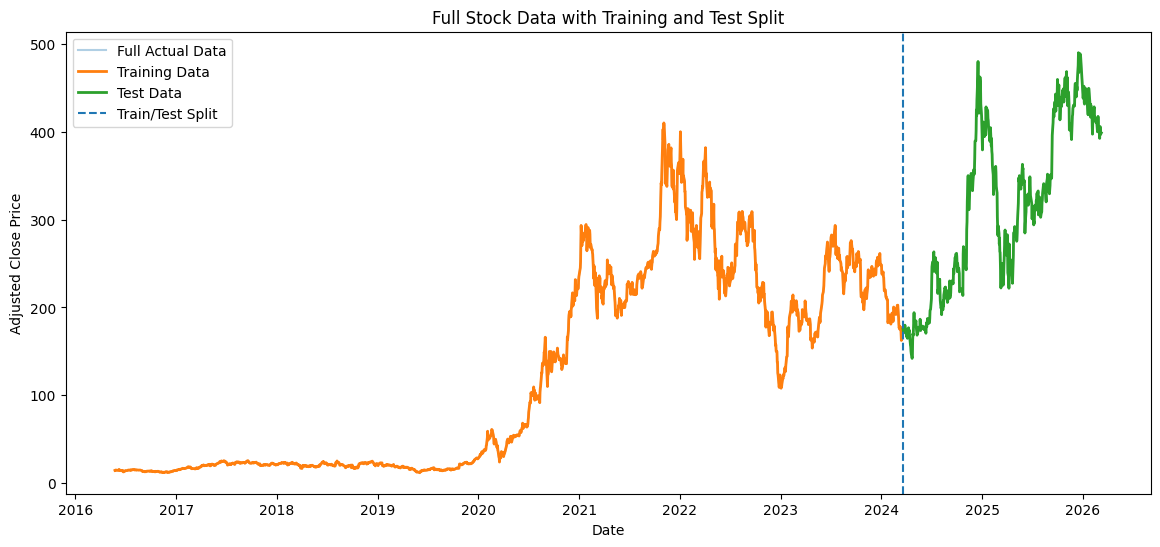

Train rows: 1968
Test rows : 493


In [ ]:
train_size = int(len(df) * TRAIN_SPLIT)

train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Adj Close'], label='Full Actual Data', alpha=0.35)
plt.plot(train_df['Date'], train_df['Adj Close'], label='Training Data', linewidth=2)
plt.plot(test_df['Date'], test_df['Adj Close'], label='Test Data', linewidth=2)

split_date = test_df['Date'].iloc[0]
plt.axvline(split_date, linestyle='--', label='Train/Test Split')

plt.title('Full Stock Data with Training and Test Split')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.show()

print("Train rows:", len(train_df))
print("Test rows :", len(test_df))

In [ ]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

train_features_scaled = feature_scaler.fit_transform(train_df[FEATURE_COLUMNS])
test_features_scaled = feature_scaler.transform(test_df[FEATURE_COLUMNS])

train_target_scaled = target_scaler.fit_transform(train_df[[TARGET_COLUMN]])
test_target_scaled = target_scaler.transform(test_df[[TARGET_COLUMN]])

In [ ]:
def create_price_sequences(features, targets, lookback):
    X, y = [], []
    for i in range(lookback, len(features)):
        X.append(features[i - lookback:i])
        y.append(targets[i])
    return np.array(X), np.array(y)

In [ ]:
X_train, y_train = create_price_sequences(train_features_scaled, train_target_scaled, LOOKBACK)
X_test, y_test = create_price_sequences(test_features_scaled, test_target_scaled, LOOKBACK)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1908, 60, 7)
y_train shape: (1908, 1)
X_test shape : (433, 60, 7)
y_test shape : (433, 1)


In [ ]:
def build_price_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        GRU(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)   # no sigmoid for regression
    ])

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

model = build_price_model((X_train.shape[1], X_train.shape[2]))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,385 (110.88 KB)

 Trainable params: 28,385 (110.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - loss: 0.0318 - mae: 0.1293 - val_loss: 0.0078 - val_mae: 0.0689
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0129 - mae: 0.0855 - val_loss: 0.0057 - val_mae: 0.0558
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.0120 - mae: 0.0834 - val_loss: 0.0060 - val_mae: 0.0575
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.0115 - mae: 0.0800 - val_loss: 0.0059 - val_mae: 0.0573
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0110 - mae: 0.0771 - val_loss: 0.0058 - val_mae: 0.0567
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.0110 - mae: 0.0772 - val_loss: 0.0060 - val_mae: 0.0584
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0103 - mae: 0.0746 - val_loss: 0.0075 - val_mae: 0.0668


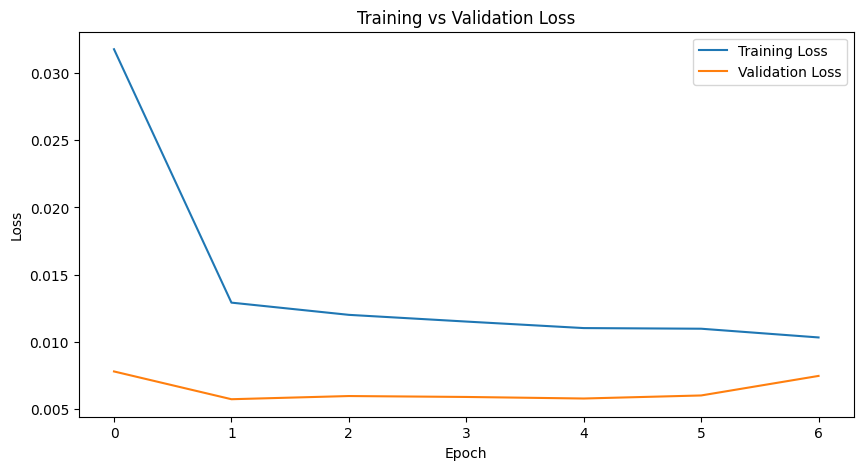

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
y_pred_scaled = model.predict(X_test)

print("Predicted scaled shape:", y_pred_scaled.shape)
print("Actual scaled shape   :", y_test.shape)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
Predicted scaled shape: (433, 1)
Actual scaled shape   : (433, 1)


In [ ]:
# ================================
# Convert predicted RETURNS → PRICE
# ================================

# Step 1: inverse transform returns
y_pred_returns = target_scaler.inverse_transform(y_pred_scaled).flatten()
y_actual_returns = target_scaler.inverse_transform(y_test).flatten()

# Step 2: align base prices correctly
# For each predicted target in the test set, use the previous day's Adj Close
base_prices = test_df['Adj Close'].iloc[LOOKBACK-1:-1].values

print("base_prices length     :", len(base_prices))
print("y_pred_returns length  :", len(y_pred_returns))
print("y_actual_returns length:", len(y_actual_returns))

# Step 3: reconstruct prices
y_pred_prices = base_prices * (1 + y_pred_returns)
y_actual_prices = base_prices * (1 + y_actual_returns)

print("First 10 predicted prices:", y_pred_prices[:10])
print("First 10 actual prices   :", y_actual_prices[:10])

base_prices length     : 433
y_pred_returns length  : 433
y_actual_returns length: 433
First 10 predicted prices: [183.59758758 179.01603458 188.75194267 186.10253647 182.62365608
 184.03460603 183.5627456  188.46225472 197.98599742 199.22849128]
First 10 actual prices   : [192.13627622 175.55979121 184.10409231 186.32607992 181.14339798
 187.79123258 191.3703384  188.35177869 196.82755523 209.3721443 ]


In [ ]:
mae = mean_absolute_error(y_actual_prices, y_pred_prices)
mse = mean_squared_error(y_actual_prices, y_pred_prices)
rmse = np.sqrt(mse)
r2 = r2_score(y_actual_prices, y_pred_prices)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 9.5869
MSE : 159.1849
RMSE: 12.6169
R²  : 0.9777


In [ ]:
test_dates = test_df['Date'].iloc[LOOKBACK:].reset_index(drop=True)

results_df = pd.DataFrame({
    'Date': test_dates,
    'Base Price': base_prices,
    'Actual Return': y_actual_returns,
    'Predicted Return': y_pred_returns,
    'Actual Price': y_actual_prices,
    'Predicted Price': y_pred_prices
})

results_df.head(20)

,Date,Base Price,Actual Return,Predicted Return,Actual Price,Predicted Price
0,2024-06-14,182.470001,0.052975,0.006180,192.136276,183.597588
1,2024-06-17,178.009995,-0.013764,0.005652,175.559791,179.016035
2,2024-06-18,187.440002,-0.017797,0.006999,184.104092,188.751943
3,2024-06-20,184.860001,0.007931,0.006722,186.326080,186.102536
4,2024-06-21,181.570007,-0.002350,0.005803,181.143398,182.623656
5,2024-06-24,183.009995,0.026126,0.005599,187.791233,184.034606
6,2024-06-25,182.580002,0.048145,0.005383,191.370338,183.562746
7,2024-06-26,187.350006,0.005347,0.005937,188.351779,188.462255
8,2024-06-27,196.369995,0.002330,0.008229,196.827555,197.985997
9,2024-06-28,197.419998,0.060542,0.009161,209.372144,199.228491


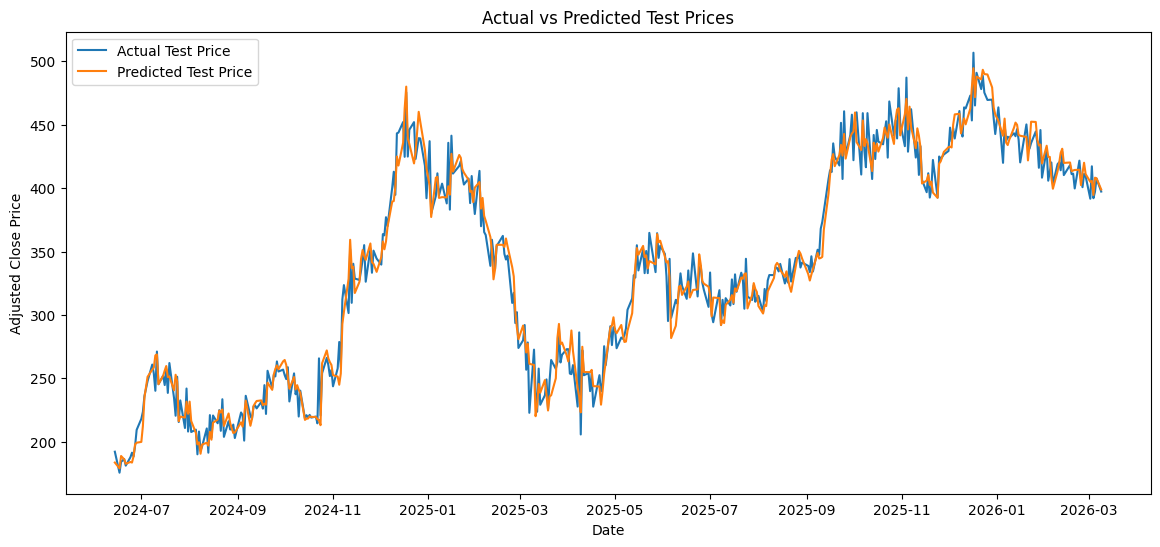

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(results_df['Date'], results_df['Actual Price'], label='Actual Test Price')
plt.plot(results_df['Date'], results_df['Predicted Price'], label='Predicted Test Price')

plt.title('Actual vs Predicted Test Prices')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.show()

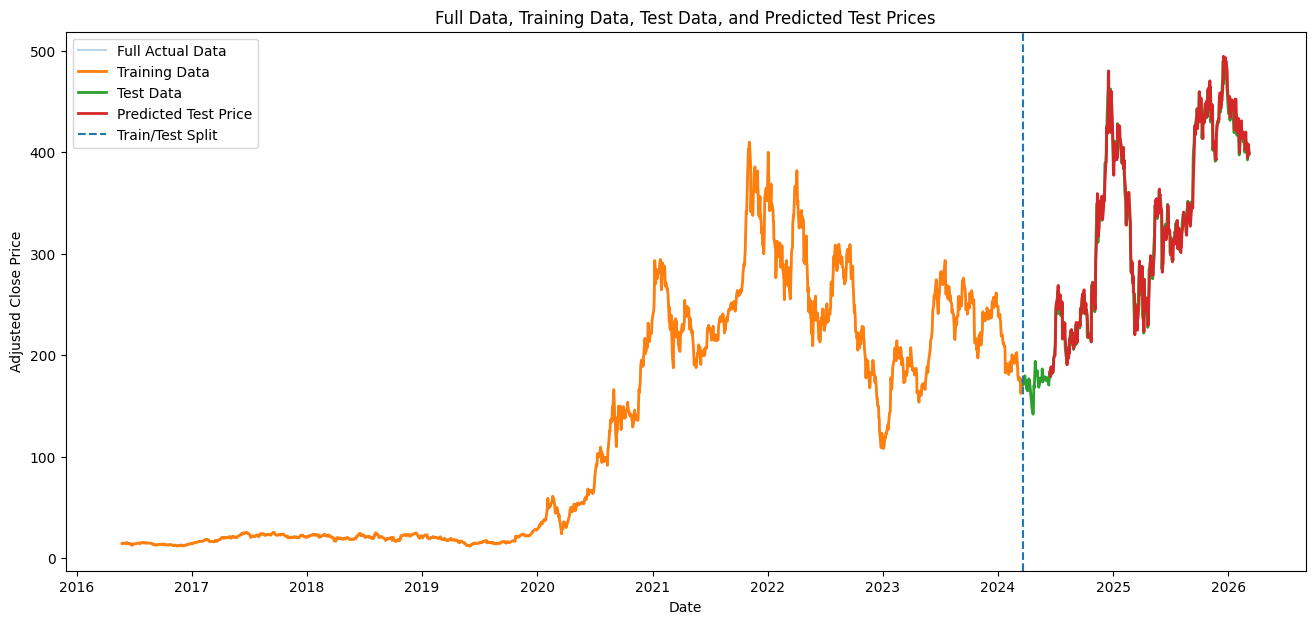

In [ ]:
plt.figure(figsize=(16, 7))

# Full actual data
plt.plot(df['Date'], df['Adj Close'], label='Full Actual Data', alpha=0.3)

# Highlight training data
plt.plot(train_df['Date'], train_df['Adj Close'], label='Training Data', linewidth=2)

# Highlight actual test data
plt.plot(test_df['Date'], test_df['Adj Close'], label='Test Data', linewidth=2)

# Predicted prices on test region
plt.plot(results_df['Date'], results_df['Predicted Price'], label='Predicted Test Price', linewidth=2)

# Split line
split_date = test_df['Date'].iloc[0]
plt.axvline(split_date, linestyle='--', label='Train/Test Split')

plt.title('Full Data, Training Data, Test Data, and Predicted Test Prices')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.show()

In [ ]:
print("Predicted UP %:", pred_direction.mean() * 100)
print("Actual UP %   :", actual_direction.mean() * 100)

Predicted UP %: 51.85185185185185
Actual UP %   : 50.92592592592593


In [ ]:
# ================================
# Direction Accuracy (UPDATED)
# ================================

# Compare movement between consecutive predicted prices
pred_direction = (y_pred_prices[1:] > y_pred_prices[:-1]).astype(int)
actual_direction = (y_actual_prices[1:] > y_actual_prices[:-1]).astype(int)

from sklearn.metrics import accuracy_score
direction_acc = accuracy_score(actual_direction, pred_direction)

print("Direction Accuracy:", direction_acc)

Direction Accuracy: 0.7222222222222222


In [ ]:
# ================================
# Direction Accuracy (UPDATED)
# ================================

pred_direction = (y_pred_prices[1:] > y_pred_prices[:-1]).astype(int)
actual_direction = (y_actual_prices[1:] > y_actual_prices[:-1]).astype(int)

from sklearn.metrics import accuracy_score
direction_acc = accuracy_score(actual_direction, pred_direction)

print("Direction Accuracy:", direction_acc)
print("Predicted UP %:", pred_direction.mean() * 100)
print("Actual UP %   :", actual_direction.mean() * 100)

Direction Accuracy: 0.7222222222222222
Predicted UP %: 51.85185185185185
Actual UP %   : 50.92592592592593


In [ ]:
# ================================
# Predict NEXT DAY PRICE
# ================================

# Step 1: Get last 60 days of features
last_sequence = df[FEATURE_COLUMNS].iloc[-LOOKBACK:].values

# Step 2: Scale using same scaler
last_sequence_scaled = feature_scaler.transform(last_sequence)

# Step 3: Reshape for model (1 sample, 60 timesteps, features)
last_sequence_scaled = np.reshape(last_sequence_scaled, (1, LOOKBACK, len(FEATURE_COLUMNS)))

# Step 4: Predict (scaled)
next_day_scaled = model.predict(last_sequence_scaled)

# Step 5: Convert back to real price
next_day_price = target_scaler.inverse_transform(next_day_scaled)

# Step 6: Print result
last_date = df['Date'].iloc[-1]

print("Last Date in Data:", last_date)
print("Last Known Price :", df['Adj Close'].iloc[-1])
print("Predicted Next Day Price:", next_day_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Last Date in Data: 2026-03-09 00:00:00
Last Known Price : 398.6799926757813
Predicted Next Day Price: 0.0053661577


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
# ================================
# Predict NEXT DAY PRICE (FIXED)
# ================================

from pandas.tseries.offsets import BDay

# Make sure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Step 1: get the last LOOKBACK rows of features
last_sequence_df = df[FEATURE_COLUMNS].iloc[-LOOKBACK:].copy()
last_sequence = last_sequence_df.values

# Step 2: scale features
last_sequence_scaled = feature_scaler.transform(last_sequence)

# Step 3: reshape for model
last_sequence_scaled = np.reshape(
    last_sequence_scaled,
    (1, LOOKBACK, len(FEATURE_COLUMNS))
)

# Step 4: predict scaled return
next_day_scaled = model.predict(last_sequence_scaled, verbose=0)

# Step 5: inverse transform to get predicted RETURN
predicted_return = target_scaler.inverse_transform(next_day_scaled)[0][0]

# Step 6: convert return to predicted next-day price
last_known_price = df['Adj Close'].iloc[-1]
predicted_next_day_price = last_known_price * (1 + predicted_return)

# Step 7: compute next business day date
last_date_in_model_data = df['Date'].iloc[-1]
predicted_date = last_date_in_model_data + BDay(1)

# Step 8: print results
print("Last Date in Model Data :", last_date_in_model_data.date())
print("Last Known Price        :", round(last_known_price, 4))
print("Predicted Return        :", round(predicted_return, 6))
print("Predicted Date          :", predicted_date.date())
print("Predicted Next Day Price:", round(predicted_next_day_price, 4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Last Date in Model Data : 2026-03-09
Last Known Price        : 398.68
Predicted Return        : 0.005366
Predicted Date          : 2026-03-10
Predicted Next Day Price: 400.8194


In [ ]:
# ==========================================
# Predict NEXT 14 DAYS with DATES
# ==========================================

future_days = 14
future_predictions = []
future_dates = []

current_sequence = df[FEATURE_COLUMNS].iloc[-LOOKBACK:].copy()
df['Date'] = pd.to_datetime(df['Date'])
last_date = df['Date'].iloc[-1]

for i in range(future_days):
    # Scale
    scaled_seq = feature_scaler.transform(current_sequence)
    scaled_seq = np.reshape(scaled_seq, (1, LOOKBACK, len(FEATURE_COLUMNS)))

    # Predict
    pred_scaled = model.predict(scaled_seq)
    pred_return = target_scaler.inverse_transform(pred_scaled)[0][0]

    last_price = current_sequence.iloc[-1]['Adj Close']
    pred_price = last_price * (1 + pred_return)

    # Store prediction
    future_predictions.append(pred_price)

    # Create next date (skip weekends optionally later)
    next_date = last_date + pd.Timedelta(days=1)
    future_dates.append(next_date)
    last_date = next_date

    # ===============================
    # Create new row (approximation)
    # ===============================

    new_row = current_sequence.iloc[-1].copy()

    # Update price
    new_row['Adj Close'] = pred_price

    # Update derived features (approximate)
    new_row['Return'] = (pred_price - current_sequence.iloc[-1]['Adj Close']) / current_sequence.iloc[-1]['Adj Close']
    new_row['MA10'] = current_sequence['Adj Close'].iloc[-10:].mean()
    new_row['MA20'] = current_sequence['Adj Close'].iloc[-20:].mean()
    new_row['MA50'] = current_sequence['Adj Close'].iloc[-50:].mean()
    new_row['Volatility10'] = current_sequence['Return'].iloc[-10:].std()
    new_row['Volume_Change'] = 0  # assume stable volume

    # Update sequence
    current_sequence = pd.concat([current_sequence.iloc[1:], new_row.to_frame().T], ignore_index=True)

# Convert to DataFrame
future_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted Price': future_predictions
})

print(future_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
         Date  Predicted Price
0  2026-03-10       400.819392
1  2026-03-11       402.934770
2  2026-03-12       405.038832
3  2026-03-13       407.144466
4  2026-03-14       409.262939
5  2026-03-15       411.403998
6  2026-03-16       413.576317
7  2026-03-17       415.778200
8  2026-03-18       418.002462
9  2026-03-19       420.257857
10 2026-03-20       422.529229
11 2026-03-21       424.827686
12 2026-03-22       427.162246
13 2026-03-23       429.53

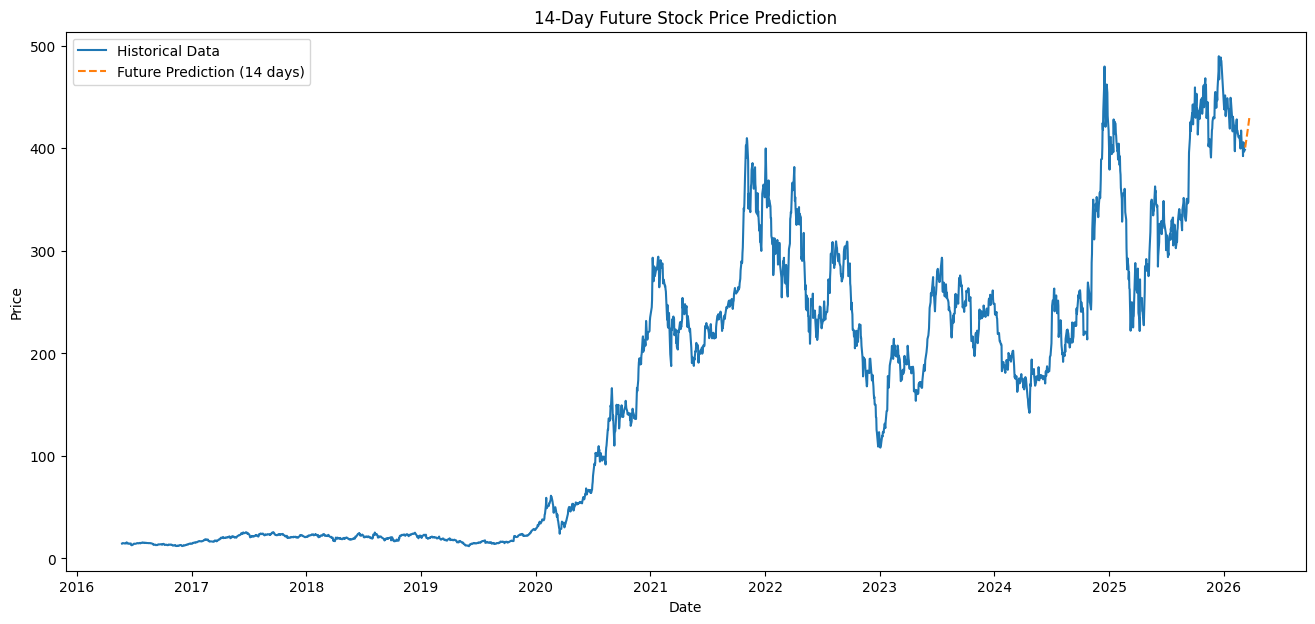

In [ ]:
plt.figure(figsize=(16, 7))

# Actual data
plt.plot(df['Date'], df['Adj Close'], label='Historical Data')

# Future predictions
plt.plot(future_df['Date'], future_df['Predicted Price'], linestyle='--', label='Future Prediction (14 days)')

plt.title('14-Day Future Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
# ==========================================
# Predict NEXT 14 DAYS with DATES
# ==========================================

future_days = 30
future_predictions = []
future_dates = []

current_sequence = df[FEATURE_COLUMNS].iloc[-LOOKBACK:].copy()
df['Date'] = pd.to_datetime(df['Date'])
last_date = df['Date'].iloc[-1]

for i in range(future_days):
    # Scale
    scaled_seq = feature_scaler.transform(current_sequence)
    scaled_seq = np.reshape(scaled_seq, (1, LOOKBACK, len(FEATURE_COLUMNS)))

    # Predict
    pred_scaled = model.predict(scaled_seq)
    pred_return = target_scaler.inverse_transform(pred_scaled)[0][0]

    last_price = current_sequence.iloc[-1]['Adj Close']
    pred_price = last_price * (1 + pred_return)

    # Store prediction
    future_predictions.append(pred_price)

    # Create next date (skip weekends optionally later)
    next_date = last_date + pd.Timedelta(days=1)
    future_dates.append(next_date)
    last_date = next_date

    # ===============================
    # Create new row (approximation)
    # ===============================

    new_row = current_sequence.iloc[-1].copy()

    # Update price
    new_row['Adj Close'] = pred_price

    # Update derived features (approximate)
    new_row['Return'] = (pred_price - current_sequence.iloc[-1]['Adj Close']) / current_sequence.iloc[-1]['Adj Close']
    new_row['MA10'] = current_sequence['Adj Close'].iloc[-10:].mean()
    new_row['MA20'] = current_sequence['Adj Close'].iloc[-20:].mean()
    new_row['MA50'] = current_sequence['Adj Close'].iloc[-50:].mean()
    new_row['Volatility10'] = current_sequence['Return'].iloc[-10:].std()
    new_row['Volume_Change'] = 0  # assume stable volume

    # Update sequence
    current_sequence = pd.concat([current_sequence.iloc[1:], new_row.to_frame().T], ignore_index=True)

# Convert to DataFrame
future_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted Price': future_predictions
})

print(future_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1

In [ ]:
# ==========================================
# FINAL COMBINED PREDICTION (DIRECTION + PRICE)
# ==========================================

from pandas.tseries.offsets import BDay

# Ensure datetime
df['Date'] = pd.to_datetime(df['Date'])

# Step 1: Get last sequence
last_sequence_df = df[FEATURE_COLUMNS].iloc[-LOOKBACK:].copy()
last_sequence = last_sequence_df.values

# Step 2: Scale
last_sequence_scaled = feature_scaler.transform(last_sequence)
last_sequence_scaled = np.reshape(
    last_sequence_scaled,
    (1, LOOKBACK, len(FEATURE_COLUMNS))
)

# Step 3: Predict return
next_day_scaled = model.predict(last_sequence_scaled, verbose=0)
predicted_return = target_scaler.inverse_transform(next_day_scaled)[0][0]

# Step 4: Convert to price
last_price = df['Adj Close'].iloc[-1]
predicted_price = last_price * (1 + predicted_return)

# Step 5: Determine direction
if predicted_return > 0:
    direction = "UP 📈"
else:
    direction = "DOWN 📉"

# Step 6: Confidence (strength of move)
confidence = abs(predicted_return)

# Step 7: Next business day
last_date = df['Date'].iloc[-1]
predicted_date = last_date + BDay(1)

# Step 8: Output
print("===================================")
print("FINAL MODEL DECISION")
print("===================================")

print("Last Date           :", last_date.date())
print("Prediction Date     :", predicted_date.date())

print("\n--- PRICE ---")
print("Last Price          :", round(last_price, 2))
print("Predicted Price     :", round(predicted_price, 2))

print("\n--- DIRECTION ---")
print("Direction           :", direction)
print("Expected Move       :", f"{predicted_return*100:.2f}%")

print("\n--- CONFIDENCE ---")
print("Strength of Signal  :", f"{confidence*100:.2f}%")

print("===================================")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


FINAL MODEL DECISION
Last Date           : 2026-03-09
Prediction Date     : 2026-03-10

--- PRICE ---
Last Price          : 398.68
Predicted Price     : 400.82

--- DIRECTION ---
Direction           : UP 📈
Expected Move       : 0.54%

--- CONFIDENCE ---
Strength of Signal  : 0.54%


In [ ]:
baseline_up = (y_actual_prices[1:] > y_actual_prices[:-1]).astype(int)
always_up = np.ones_like(baseline_up)

from sklearn.metrics import accuracy_score
baseline_acc = accuracy_score(baseline_up, always_up)

print("Baseline (Always UP) Accuracy:", baseline_acc)

Baseline (Always UP) Accuracy: 0.5092592592592593


In [ ]:
random_pred = np.random.randint(0, 2, size=len(actual_direction))
baseline_random = accuracy_score(actual_direction, random_pred)

print("Baseline (Random) Accuracy:", baseline_random)

Baseline (Random) Accuracy: 0.5185185185185185


In [ ]:
baseline_pred = base_prices  # assume no movement

mae_baseline = mean_absolute_error(y_actual_prices, baseline_pred)
rmse_baseline = np.sqrt(mean_squared_error(y_actual_prices, baseline_pred))

print("Baseline MAE :", mae_baseline)
print("Baseline RMSE:", rmse_baseline)

Baseline MAE : 9.309618832838723
Baseline RMSE: 12.381990967970099


In [ ]:
import os

BASE_PATH = "project"

MODEL_PATH = os.path.join(BASE_PATH, "models")
DATA_PATH = os.path.join(BASE_PATH, "data")
RESULT_PATH = os.path.join(BASE_PATH, "results")

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(RESULT_PATH, exist_ok=True)

print("Folders created!")

Folders created!


In [ ]:
# Save trained model
model.save(os.path.join(MODEL_PATH, "lstm_model.h5"))

print("Model saved!")

Model saved!


In [ ]:
import joblib

joblib.dump(feature_scaler, os.path.join(MODEL_PATH, "feature_scaler.pkl"))
joblib.dump(target_scaler, os.path.join(MODEL_PATH, "target_scaler.pkl"))

print("Scalers saved!")

Scalers saved!


In [ ]:
df.to_csv(os.path.join(DATA_PATH, "processed_data.csv"), index=False)

print("Processed data saved!")

Processed data saved!


In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Actual Price": y_actual_prices,
    "Predicted Price": y_pred_prices
})

results_df.to_csv(os.path.join(RESULT_PATH, "predictions.csv"), index=False)

print("Predictions saved!")

Predictions saved!


In [ ]:
future_df.to_csv(os.path.join(RESULT_PATH, "future_predictions.csv"), index=False)

print("Future predictions saved!")

Future predictions saved!


In [ ]:
# from tensorflow.keras.models import load_model
# import joblib
# import pandas as pd

# # Load model
# model = load_model("project/models/lstm_model.h5")

# # Load scalers
# feature_scaler = joblib.load("project/models/feature_scaler.pkl")
# target_scaler = joblib.load("project/models/target_scaler.pkl")

# # Load data
# df = pd.read_csv("project/data/processed_data.csv")

# # Load predictions
# results_df = pd.read_csv("project/results/predictions.csv")